## __`CS : Compressed Sensing of Images`__
Ce notebook explore l’acquisition comprimée (compressed sensing) d’images naturelles, en évaluant plusieurs modèles de parcimonie des coefficients dans une base d’ondelettes, afin d’améliorer la qualité de reconstruction à partir d’un nombre réduit de mesures. La théorie du "compressed sensing" / "sparsity", revêt 
#### _`Cadre de base`_
On observe un **signal** $m \in \mathbb{R}^N$ `via des mesures linéaires` tel que :

$$\Large y = A m \text{ <> } \Large y = A(\Psi^{-1}x)$$
Dans ce régime M≪N, le système est sous‑déterminé car il existe une infinité de $m$ compatibles avec $y$. La matrice A décrit comment l’appareil de mesure combine les composantes de m (optique, capteur, lignes de k‑espace en IRM, etc.).
- N dimension du signal (longueur du vecteur ou nombre de pixels)
- M nombre de mesures (nombre de lignes de A)
- $m\in R^N$ le signal dans le domaine original (image, son, etc.)
- $A \in \mathbb{R}^{M \times N}$ est une matrice de mesure et $M \ll N$
- $y\in R^M$ vecteur de mesures 

Ici, les composantes de y représentent les mesures physiques fournies par le dispositif d’acquisition (combinaisons linéaires de pixels), alors que les “coefficients” sparsifiés désignent les composantes de $x = \Psi m $ dans une base adaptée (ondelettes, etc.), sur lesquelles on impose la parcimonie.

La théorie du compressed sensing s’appuie alors sur l’idée que l'on peut reconstruire un signal à partir de beaucoup moins de mesures que sa dimension, à condition qu’il soit parcimonieux/sparse c-a-d que la plupart de ses coefficients soient nuls dans une base adaptée.
$$\Large x = \Psi m \text{ <=> } \Large m = \Psi^{-1} x$$
- $x$ le signal sparse, c’est‑à‑dire ses coefficients dans la base $\Psi$ (ondelettes, Fourier, …),.
- $\Psi$ transforme le signal $m$ en représentation sparse $x$ (ondelettes, Fourier, etc,).
- $m\in R^N$ le signal dans le domaine original (image, son, etc.)
- $\Psi^{-1}$ opérateur inverse qui reconstruit $m$ à partir de $x$.

#### _`Rôle de la parcimonie`_
La parcimonie sert à sélectionner, parmi toutes les solutions compatibles avec les mesures, celle dont la représentation $x$ dans la base $\Psi$ est la plus “rare” (peu de coefficients non nuls).
- $ \small \text{On souhaiterait résoudre : }\large \min_{x} \|x\|_0 \small \text{ sous la contrainte } \large  y = A \Psi^{-1} x$
Mais ce problème en $\ell_0$ est combinatoire et NP‑difficile, 
- $ \small \text{On le remplace donc par } \large \min_{x} \|x\|_1 \small\text{ sous la contrainte } \large y = A \Psi^{-1} x \small \text{ convexe sous hypothèses appropriées sur A}$

La minimisation en norme $\ell_1$ permet de retrouver la solution parcimonieuse, même lorsque $M \ll N$.
- l’astuce de CS est d’ajouter l’hypothèse de parcimonie sur le signal, 
- on suppose qu’il admet une représentation $x = \Psi.m$, dans une base ou dictionnaire $\Psi$, 
- $x$ est K‑parcimonieux, si le vecteur $x$ ne possède qu'un petit nombre $K$ de coefficients non nuls, 
- tel qu'écrit $x = \Psi.\alpha$ avec $\alpha$ ayant peu de coefficients significatifs dans une base $\Psi$.

#### `Intuition pour les images naturelles`
Pour une image $m$, on prend souvent $x = \Psi \alpha$ avec $\Psi$ base d’ondelettes, car :
- les images naturelles ont des coefficients d’ondelettes qui décroissent vite avec l’échelle.  
- elles sont bien approchées par un **petit nombre** de coefficients significatifs (bords, contours),
- donc $\alpha$ est parcimonieux ou compressible. 
`De ce fait l'on peut:`
1. Mesurer directement $y = A.m$ avec $M \ll N$.  
2. Reconstruire $\hat m$ en résolvant un problème de minimisation $\ell_1$ sur les coefficients ondelettes. 
##### __`Synthèse`__
On cherche à reconstruire un signal $x∈R^N$ à partir d’un nombre de mesures linéaires $M≪N$, données par $y=Ax$. 
_`La clé est l’hypothèse de parcimonie suppose que:`_ 
- $x$ est sparse ou compressible dans une base adaptée, c-a-d qu’il peut s’écrire $x=\Phi\alpha$ 
- avec un vecteur de coefficients $\alpha$ comportant peu de composantes significatives. 
- sous des hypothèses appropriées sur la matrice de mesure $A$ (incohérence, propriété de type RIP),
- on peut retrouver $x$ en résolvant un problème de minimisation de norme $\ell_1$ sur les coefficients $\alpha$, 
- permettant une reconstruction fidèle malgré un sous‑échantillonnage important.

In [3]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

#### `Filtre "passe-bas" mesures linéaires`
`Utiliser les mesures d'un filtre "pass-bas" pour retirer les basses fréquences de l'image`.
 - les images naturelles ne sont pas seulement parcimonieuses dans le domaine des ondelettes. 
 - elles présentent également une décroissance rapide des coefficients au fil des échelles. 
 - la graine d'ondelette grossières (passe-bas) concentrent une grande partie de l’énergie de l’image.
 - il est donc pertinent de mesurer directement les coefficients "pass-bas"
`Opérationnellement : `
 - cela revient à appliquer une décomposition en ondelettes, 
 - à extraire les coefficients d’approximation de niveau grossier, 
 - on met à zéro les coefficients $C_A$ d'approximation issus du passe‑bas.
 - puis à annuler ces coefficients lors de la reconstruction pour obtenir une image sans basses fréquences. » 

Maintenant nous chargeons une image $m \in \mathcal{R}^{n^2}$ de $n \times n$ pixels.

(512, 512)


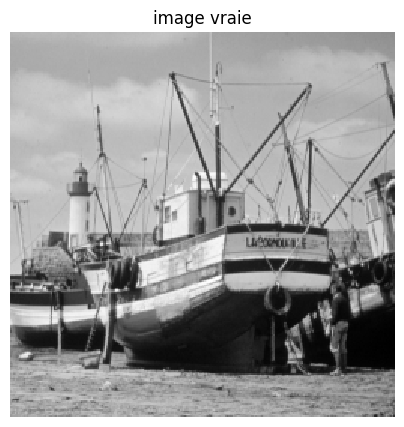

In [4]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/boat.bmp'
n = 512

f0 = load_image(name,n)          # f0.shape = (256, 256)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)

from skimage.transform import rescale

f0= rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(5, 5))
imageplot(clamp(f0),'image vraie')

`Raccourci pour les transformés en ondelettes` $\{ \langle f, \Psi_m \rangle \}_m$
- Nous calculons la transformée jusqu'à l'échelle $J$ de sorte que seuls les sous-bandes $k_0$ sont transformées.
- Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base.

Définition de $P_f$ opérateur de projection passe‑bas sur l’espace d’approximation d’échelle J en fonction des coefficients d’approximation ondelettes $\Phi_{J,k}$ :
-  $P_f=\sum_k⟨f,\Phi_{J,k} ⟩\Phi_{J,k})$ et son lien avec la primitive wavedec2 

Mathématiquement, nous avons une décomposition du type où : 
- $\large f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$

  - $\Phi_{J,k}$ sont les fonctions d’échelle
  - $\Psi_{j,k}$ les ondelettes.
  - cA_J le premier bloc concatèné correspond aux coefficients d'approximation grossier basse fréquences.
  - cD_1, cD_2,.., cD_J sont les blocs suivants sont les coefficientsde détails de plus en plus grossiers suivant l'ordre.

Sert à fixer la plus petite échelle de la transformée en ondelettes, jusqu’à où descendre dans les décompositions en résolution.

`Que représente un coefficient`
Pour chaque échelle J et la position k :
- $\Phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\Psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle J et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

#### `Transformée en ondelettes discrètes 2D directe et inverse` 

In [5]:
import pywt
import numpy as np

# perform_direct_wavelet_transf transformée directe est un opérateur qui prend une image f 
# et renvoie ses coefficients d’ondelettes.
def perform_direct_wavelet_transf(f,n,k0,wavelet):
    # par ex., à adapter à ce que fait options.wavelet
    w = pywt.Wavelet(wavelet)
    # 2D image : f is 2D array
    coeffs_ti_2d = pywt.wavedec2(f, wavelet=w, level=k0, mode='periodization')
    return coeffs_ti_2d

# perform_inverse_wavelet_transf l’opérateur inverse qui à partir des coefficients d’ondelettes, 
# reconstruit l’image, en appelant.
def perform_inverse_wavelet_transf(coeffs,wavelet):
    # 2D image : f is 2D array
    w = pywt.Wavelet(wavelet)
    f_rec = pywt.waverec2(coeffs, wavelet=w, mode='periodization')
    return f_rec

`Calculer la transformée en ondelette.`

In [6]:
wavelet='sym8'
k0=3

coeffs_ti_2d = perform_direct_wavelet_transf(f0,n,k0,wavelet)# [cA_J, (cH_J,cV_J,cD_J), ..., (cH_1,cV_1,cD_1)]
# Approximation au niveau le plus grossier
cA = coeffs_ti_2d[0]
print(f"cA_J : {cA.shape}, len(coeffs_ti_2d[1:] : {len(coeffs_ti_2d[1:])}), len(coeffs_ti_2d) : {len(coeffs_ti_2d)}\n")
# Détails : du niveau J jusqu'au niveau 1
for j, (cH, cV, cD) in enumerate(coeffs_ti_2d[1:], start=1):
    level = len(coeffs_ti_2d) - j   # juste pour numéroter J, J-1, ..., 1
    print(f"{j} Level {level}: cH_{level} {cH.shape}, cV_{level} {cV.shape}, cD_{level} {cD.shape}")

cA_J : (32, 32), len(coeffs_ti_2d[1:] : 3), len(coeffs_ti_2d) : 4

1 Level 3: cH_3 (32, 32), cV_3 (32, 32), cD_3 (32, 32)
2 Level 2: cH_2 (64, 64), cV_2 (64, 64), cD_2 (64, 64)
3 Level 1: cH_1 (128, 128), cV_1 (128, 128), cD_1 (128, 128)


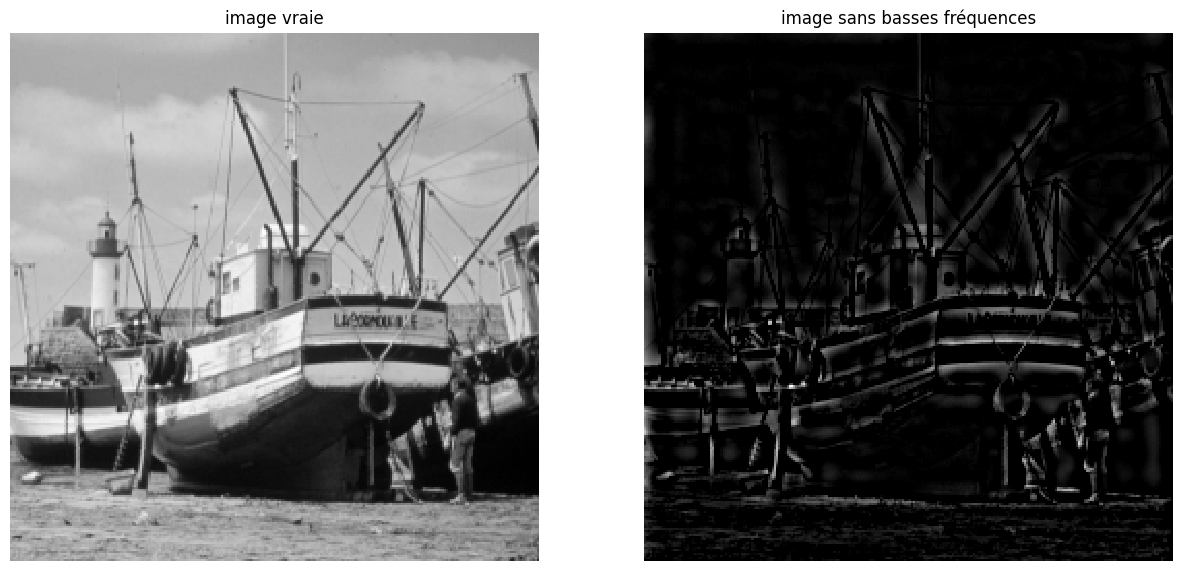

In [7]:
# Mise à zéro de cA (basses fréquences)
cA, details = coeffs_ti_2d[0], coeffs_ti_2d[1:]
cA_zero = np.zeros_like(cA)
coeffs_high = [cA_zero] + list(details)
f_vec = perform_inverse_wavelet_transf(coeffs_high,wavelet)
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_vec),'image sans basses fréquences',[1,2,2])

- LL = approximation → tons clairs uniformes (ciel, murs lisses)
- LH = contours verticaux  → hautes fréquences
- HL = contours horizontaux → hautes fréquences  
- HH = contours diagonaux   → hautes fréquences

On décompose l’image par ondelettes, ensuite nous annulons les coefficients d’approximation (passe‑bas), puis on reconstruit à partir des seuls coefficients de détail. Le résultat est une image où la composante basse fréquence a été retirée, ne laissant visibles que les structures de haute fréquence (contours, textures).

#### __`Exercice 1`__
Construire une approximation basse fréquence $∣f_{low}∣$ 
- Ne conserver que les coefficients passe‑bas, au nombre de $P=2^{2^J} =(n/k_0)^2$ : 
  - image est de taille $n×n$.
  - on travaille avec une décomposition ondelette 2D à $J=log2(n)−k0$ niveaux.
  - au niveau le plus grossier, le bloc basse fréquence (cA_J) est de taille $(n/2^{k_0})×(n/2^{k_0})$.
  - si on note $2^{k_0}=k_0$ => $(n/2^{k_0})×(n/2^{k_0}) \equiv (n/{k_0})^2$ => $P=2^{2^J} =(n/k_0)^2$
  - P correspond au nombre de coefficients passe‑bas utilisés pour construire $f_{low}$

cA.shape : (32, 32), 64*64 : 4096, f_low.shape : (256, 256)


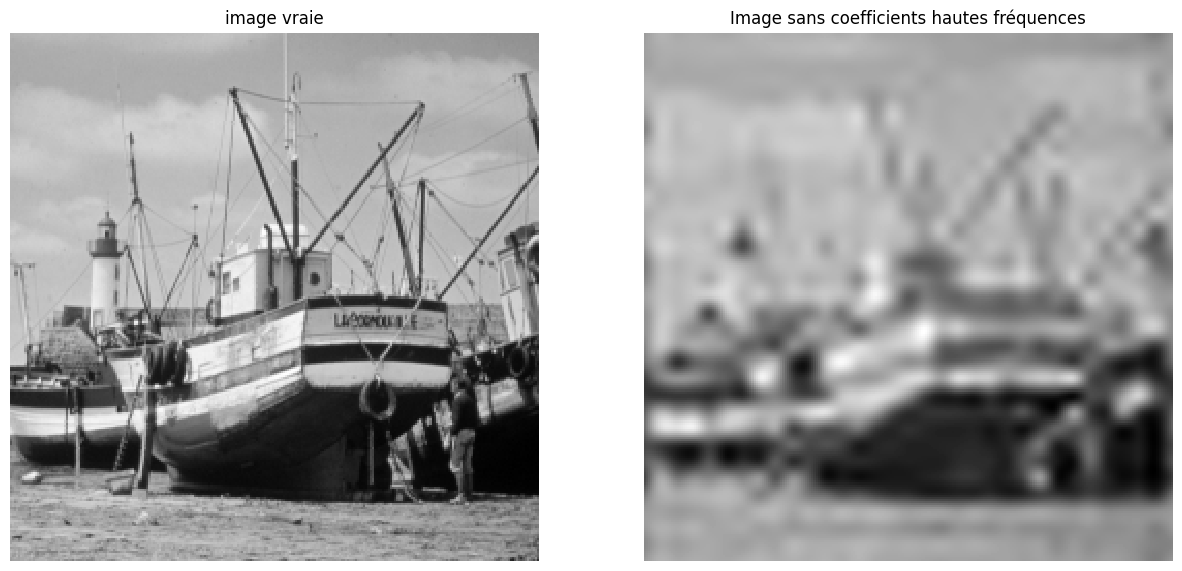

In [8]:
details_zero = [(np.zeros_like(cH), np.zeros_like(cV),np.zeros_like(cD)) for (cH, cV, cD) in details]
coeffs_low = [cA] + details_zero
f_low = perform_inverse_wavelet_transf(coeffs_low,wavelet)
print(f"cA.shape : {cA.shape}, 64*64 : {64*64}, f_low.shape : {f_low.shape}")
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_low),f'Image sans coefficients hautes fréquences',[1,2,2])


### `Mesures orthogonales aléatoires`.
- Considérons un opérateur "compressed sensing" qui correspond à une projection orthogonal randomisée.
- Extraire les coefficients d'ondelettes haute-fréquences $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$.
   - A est un masque $n×n$ rempli de 1.
   - on met à 0 le bloc supérieur gauche de taille $2^J×2^J$
   - A == 0 = zone low-pass, 
   - A == 1 = zone high-pass

<table border="1" style="border-collapse:collapse; text-align:center; font-family:monospace;">
  <tr>
    <td style="width:30px; height:30px;">0<br><small>LL</small></td>
    <td style="width:30px; height:30px;">1<br><small>LH</small></td>
    <td rowspan="2" style="width:60px; height:60px;">1<br><small>LH</small></td>
  </tr>
  <tr>
    <td style="width:30px; height:30px;">1<br><small>HL</small></td>
    <td style="width:30px; height:30px;">1<br><small>HH</small></td>
  </tr>
  <tr>
    <td colspan="2" style="width:60px; height:60px;">1<br><small>HL</small></td>
    <td style="width:60px; height:60px;">1<br><small>HH</small></td>
  </tr>
</table>
<div>
</div>

| Zone                                           | Valeur dans A | Rôle                             |
| ---------------------------------------------- | ------------- | -------------------------------- |
| Bloc $2^J \times 2^J$ en haut à gauche | 0             | Low-pass (exclus de $I_0$)    |
| Tout le reste                                  | 1             | High-pass (inclus dans $I_0​$) |

#### `Extrait du vecteur de coefficients d'ondelettes haute-fréquence` 
$$\large x_0={⟨f,ψ.m⟩}m∈I_0$$
- `pywt.coeffs_to_array` reconstruit l'image de coefficients (n x n) d'un coup et retourne : 
- `fw_img :`Recolle toutes les sous-bandes en une seule image 2D
- `slices :`Retourne les positions de chaque sous-bande dans fw_img

In [9]:
# Reconstruire l'image de coefficients (n x n) d'un coup
# fw_img — Recolle toutes les sous-bandes en une seule image 2D
# slices — Retourne les positions de chaque sous-bande dans fw_img
fw_img, slices = pywt.coeffs_to_array(coeffs_ti_2d)
s_low = slices[0]
low_h = s_low[0].stop
low_w = s_low[1].stop
A = np.ones((fw_img.shape))  
A[0:low_w,0:low_h] = 0
# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]
x0 = fw_img.flatten()[I0]

print(f"low_h : {low_h}, low_w : {low_w}  => {low_h**2}")
print(f"A.shape : {A.shape} => {A.flatten().shape}")
print(f"I0.shape : {I0.shape} => len(I0)+low_h**2 : {len(I0)+low_h**2}")
print(f"Nombre de niveaux : {len(coeffs_ti_2d) - 1}, fw_img.shape : {fw_img.shape}, {fw_img.shape[0]*fw_img.shape[0]} , A.shape : {A.shape}, I0.shape : {I0.shape}")
print(f"Le nombre de coefficients haute fréquence est : {len(x0)}, (len(x0)+low_h**2) : {len(x0)+low_h**2}")

low_h : 32, low_w : 32  => 1024
A.shape : (256, 256) => (65536,)
I0.shape : (64512,) => len(I0)+low_h**2 : 65536
Nombre de niveaux : 3, fw_img.shape : (256, 256), 65536 , A.shape : (256, 256), I0.shape : (64512,)
Le nombre de coefficients haute fréquence est : 64512, (len(x0)+low_h**2) : 65536


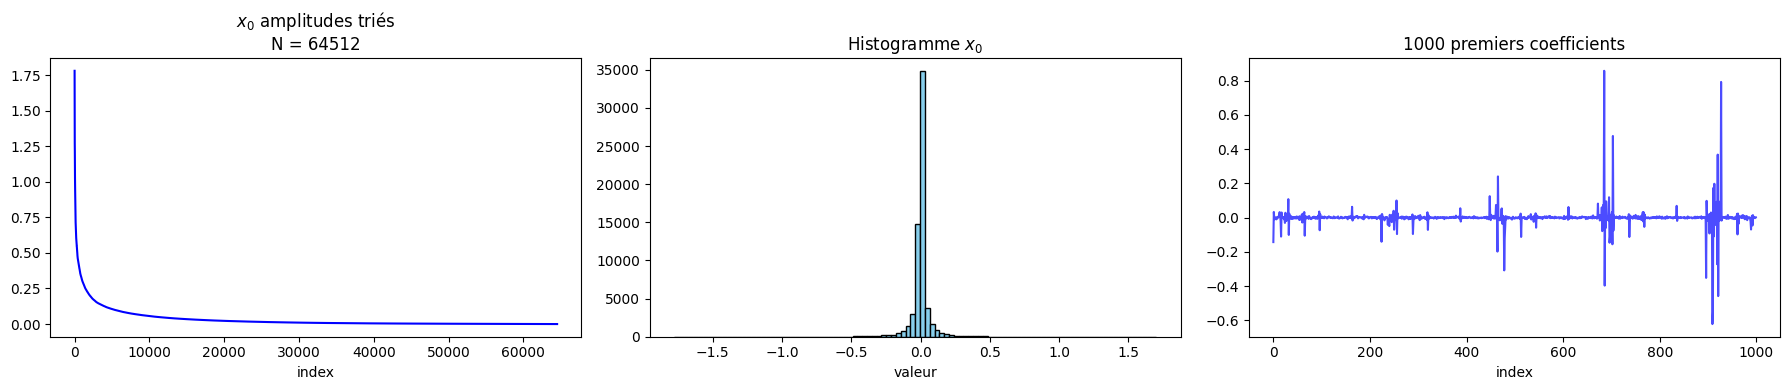

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Amplitudes triées
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ amplitudes triés\nN = {len(x0)}')
axes[0].set_xlabel('index')

# 2. Histogramme
axes[1].hist(x0, bins=100, color='skyblue', edgecolor='k')
axes[1].set_title(f'Histogramme $x_0$')
axes[1].set_xlabel('valeur')

# 3. Zoom sur les 1000 premiers
axes[2].plot(x0[:1000], 'b-', alpha=0.7)
axes[2].set_title(f'1000 premiers coefficients')
axes[2].set_xlabel('index')

plt.tight_layout()
plt.show()

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse !

- `Figure 2:` Pic très marqué autour de 0 → la grande majorité des coefficients sont quasi nuls, confirmant la parcimonie vue dans la figure 1.

- `Figure 3:` Les coefficients oscillent autour de 0 avec quelques pics occasionnels. C'est typique des coefficients d'ondelettes où la plupart sont proches de 0, seuls quelques-uns (les contours de l'image) ont une amplitude significative.

#### `Nombre de mesures CS (acquisition ou mesure comprimée)`
__Idée principale__
- En traitement du signal classique (théorème de Shannon-Nyquist), 
- il faut au moins autant de mesures que de coefficients pour reconstruire un signal.
_`Le Compressed Sensing dit`_ : 
- si le signal est parcimonieux (sparse), 
- c'est-à-dire que la plupart de ses coefficients sont nuls ou quasi-nuls, 
- alors on peut le reconstruire avec beaucoup moins de mesures : $P<<N$

#### `Nombre de mesures basses fréquences:` 
 - $P_0 = 2^{2J}=(n/2^{k_0})^2 $

In [11]:
P0 = (n/2**k0)**2
print(f"Le nombre de de mesures basse fréquence {P0}")

Le nombre de de mesures basse fréquence 4096.0


##### __`Operateurs de permutations aléatoires`__ 
 - $S_1,S_2 : \mathcal{R}^N \rightarrow \mathcal{R}^N$ tel que $S_k(x)_i = x_{\sigma_k(i)}$ où $ \sigma_k \in \Sigma_N $ 
- soit une permutation aléatoire $\{1,\ldots,N\}$.

In [12]:
N = len(x0)   # 64512
print(f"Le nombre de coefficients basse fréquences N = {len(x0)}")

# Deux permutations aléatoires sigma_1 et sigma_2
sigma1 = np.random.permutation(N)   # σ_1
sigma2 = np.random.permutation(N)   # σ_2

# Opérateurs directs
S  = lambda x,sigma: x[sigma]
# Opérateurs S_1 et S_2 appliqués à x0
S1_x0 = S(x0,sigma1)
S2_x0 = S(x0,sigma2)

Le nombre de coefficients basse fréquences N = 64512


##### __`Opérateurs adjoints ou inverses`__ 
 - $S_1^*,S_2^*$ (notés |$S_1^S, S_2^S|$) 
 - correspondant à la permutation inverse $\sigma_k^*$ tel que  $\sigma_k^* \circ \sigma_k(i)=i$.

In [13]:
# Permutations inverses (adjoints)
sigma1S = np.zeros(N, dtype=int)
sigma1S[sigma1] = np.arange(N)

sigma2S = np.zeros(N, dtype=int)
sigma2S[sigma2] = np.arange(N)

# Opérateurs inverses (adjoints)
Sinv_1 = lambda x,sigma1S: x[sigma1S]
Sinv_2 = lambda x,sigma2S: x[sigma2S]

##### __`Opérateur CS (acquisition ou mesure comprimée):`__ 
- $ \Phi:\mathcal{R}^N \rightarrow \mathcal{R}^P$ 
Une projection sur des atomes aléatoires correspond aux vecteurs colonnes de la matrice de mesure: 
- $ \Phi = [\Phi_1,\Phi_2,…,\Phi_N]$
 - $\Phi x = \begin{pmatrix} \langle x, \phi_1 \rangle & \langle x, \phi_2 \rangle & \cdots & \langle x, \phi_P \rangle \end{pmatrix}^\top$
 - $ (\Phi x)_i = \langle{x}{\Phi_{\sigma_2(i)}}\rangle $ 
   - ou $ \Phi_i $ est une base orthogonale mélangée (scrambled) : $ \Phi_i(x) = \large c_i( \sigma_1(x) ) $
   - où $\{ c_i \}_i$ est la base orthogonale DCT (Transformée en Cosinus Discrète).
`Cette opérateur peut s'écrire sous une forme compacte :` 
 - $ \Phi x = ( S_2 \circ C \circ S_1 (x) ) \downarrow_P $
   - où $S_1,S_2$ sont les opérateurs de permutation, 
   - et $\downarrow_P$ sélectionne les $P$ premières entrées du vecteur.
   - Attention se lit de gauche vers droite (application fonctionnelle) :
     - $S_1(x)   →   C(S_1(x))   →   S_2(C(S_1(x)))   →   [·]↓_P$
   - Attention à la notation compacte (algèbre linéaire) :
     - $Φ = ↓_P ∘ S_2 ∘ C ∘ S_1$ 

x (vecteur N coefficients high-pass)
Phi(x) = dP( S2( C( S1(x) ) ) )
    S1(x) : permutation aléatoire σ1
        ↓
    C(…)  : transformée DCT orthogonale
        ↓
    S2(…) : permutation aléatoire σ2
        ↓
    dP(…) : garder les P premières entrées  
        ↓ 
    y = Φx  (vecteur de P mesures)

In [14]:
from scipy.fft import dct, idct

P = N // 4   # nombre de mesures Shanon-Nyquist 
print(f" N: {N} P: {P}  P ≪ N")
# DCT orthogonale et son inverse
C     = lambda x: dct(x, norm='ortho')  # transformée en cosinus discrete dans une base orthogonale
Cinv  = lambda x: idct(x, norm='ortho') # transformée en cosinus discrete inverse dans une base orthogonale
dP    = lambda x,P: x[:P] # Sous-échantillonnage ↓_P : garder les P premières entrées
Phi   = lambda x,sigma1,sigma2,P: dP(S(C(S(x,sigma1)),sigma2),P) # Opérateur Φ : R^N → R^P

 N: 64512 P: 16128  P ≪ N


- $\large x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition ou de mesures comprimées

In [15]:
# opérateur d'acquisition ou de mesures comprimées
y = Phi(x0,sigma1,sigma2,P)
print(f"x0.shape : {x0.shape}")       # (N,)  = (15360,)
print(f"y.shape  : {y.shape}")        # (P,)  = (3840,)

x0.shape : (64512,)
y.shape  : (16128,)


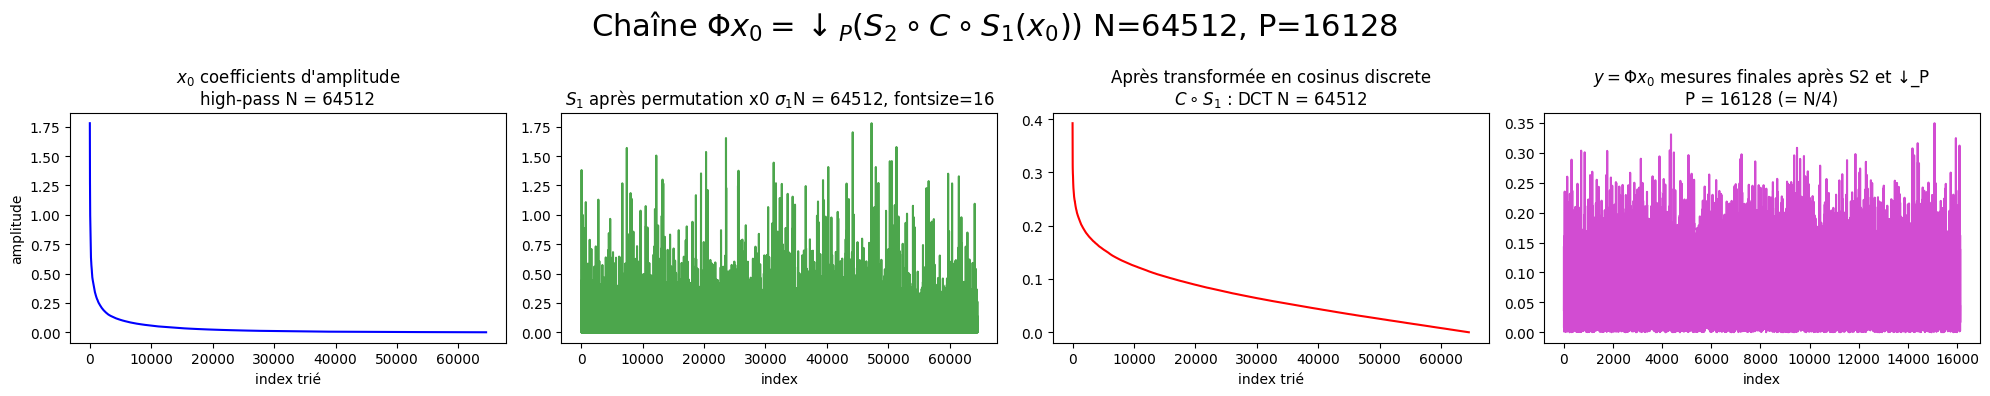

Nombre de coefficient haute fréquence : 64512
Nombre de mesures finales : 16128


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. x0 : coefficients high-pass originaux
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ coefficients d\'amplitude\nhigh-pass N = {N}')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. Après S1 : permutation sigma1
S1_x0 = S(x0, sigma1)
axes[1].plot(np.abs(S1_x0), 'g-', alpha=0.7)
axes[1].set_title(f'$S_1$ après permutation x0 $\\sigma_1$N = {N}, fontsize=16')
axes[1].set_xlabel('index')

# 3. Après C∘S1 : DCT
CS1_x0 = C(S1_x0)
axes[2].plot(np.sort(np.abs(CS1_x0))[::-1], 'r-')
axes[2].set_title(f'Après transformée en cosinus discrete\n$C \\circ S_1$ : DCT N = {N}')
axes[2].set_xlabel('index trié')

# 4. y = Φx0 : mesures finales après S2 et ↓_P
axes[3].plot(np.abs(y), 'm-', alpha=0.7)
axes[3].set_title(f'$y = \\Phi x_0$ mesures finales après S2 et ↓_P\nP = {P} (= N/4)')
axes[3].set_xlabel('index')

plt.suptitle(f'Chaîne $\\Phi x_0 = \\downarrow_P(S_2 \\circ C \\circ S_1(x_0))$'f' N={N}, P={P}', fontsize=22)
plt.tight_layout()
plt.show()

print(f"Nombre de coefficient haute fréquence : {x0.shape[0]}")   # (N,)
print(f"Nombre de mesures finales : {y.shape[0]}")    # (P,)

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute-fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse!

- `Figure 2:` Les coefficients sont mélangés aléatoirement par la permutation $\sigma_1$. L'amplitude totale est conservée (même norme), mais l'ordre est perdu. C'est une étape de scrambling pour que l'information soit répartie uniformément avant la DCT.

- `Figure 3:` DCT concentre l'énergie, quelques coefficients ont une grande amplitude (à gauche) et le reste est quasi nul. La DCT est une base adaptée qui compresse encore mieux l'information que la base ondelette originale. C'est ce qui rend les mesures très efficaces.

- `Figure 4:` Les P = N/4 => 15360 mesures finales. Chaque valeur est le produit scalaire entre $x_0$ et un atome aléatoire. L'amplitude est distribuée uniformément entre toutes les mesures grâce au mélange $S_2 \circ C \circ S_1$. On a réduit N=61440 → P=15360 coefficients tout en préservant l'information essentielle.


_`Rappel :`_
- $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition ou de mesures comprimées
_`L'opérateur adjoint est :`_ 
 - $ \Phi^* x = S_1^* \circ C^* \circ S_2^* (x) \circ \uparrow_P $ 
 - `où` $\uparrow_P$ `ajoute  N - P zéros à la fin d'un vecteur` 
 - $C^*$ est la transformée cosinus discrète inverse.
 - Attention se lit de gauche vers droite (application fonctionnelle) : $S_2^*(x)   →   C^*(S_2^*(x))   →   S_1^*(C^*(S_1^*(x)))→ [·]\uparrow_P$
 - Attention à la notation compacte (algèbre linéaire) :$\Phi^*  = S_1^* ∘  C^*  ∘  S_2^* ∘  \uparrow_P$

In [17]:
# Φ* : R^P → R^N
uparrow = lambda x,N,P: np.concatenate([x, np.zeros(N - P)])
# L'opérateur adjoint 
PhiS  = lambda x,N,P,sigma1S,sigma2S: Sinv_1(Cinv(Sinv_2(uparrow(x,N,P), sigma2S)),sigma1S)

Effectuer les mesures de compressed sensing Perform CS (sans bruitage).

In [18]:
# l'opérateur d'acquisition de mesures
y = Phi(x0,sigma1,sigma2,P)
# L'opérateur adjoint 
z = PhiS(y,N,P,sigma1S,sigma2S)
print(f"phiS.shape : {z.shape},\nz : {z}")

phiS.shape : (64512,),
z : [-0.03290342  0.09133683 -0.03326734 ...  0.00369239 -0.0226886
  0.05472699]


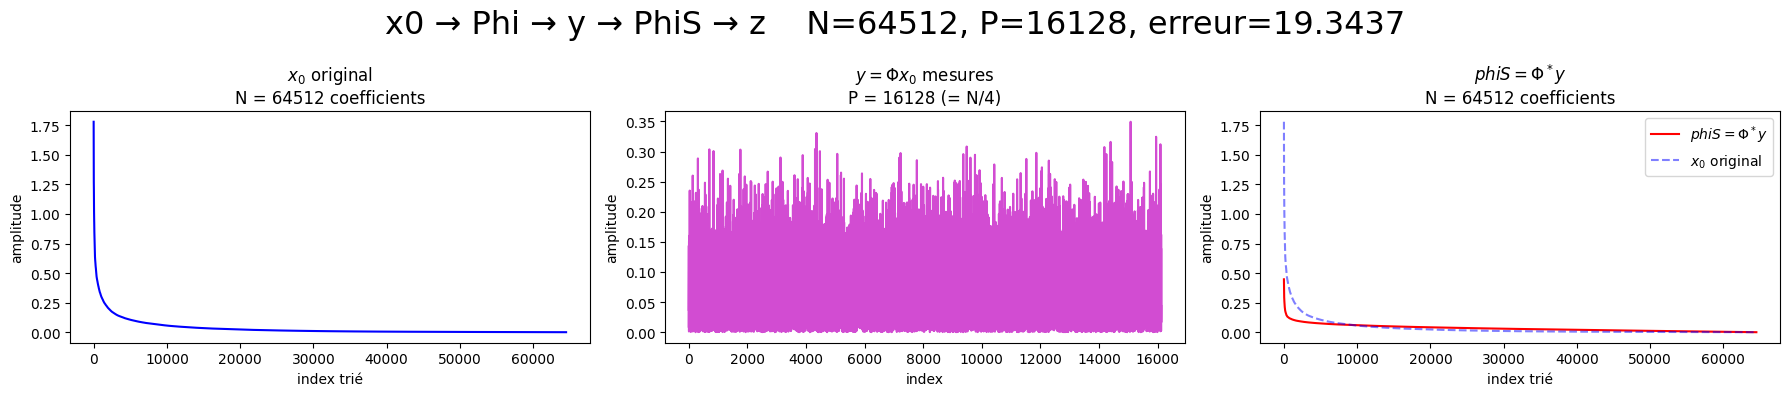

x0.shape          : (64512,)
y.shape           : (16128,)
z.shape           : (64512,)
||phiS - x0||     : 19.343686
||x0||            : 22.343946
erreur relative   : 0.865724


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. x0 original
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ original\nN = {N} coefficients')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. y = Φx0 : mesures
axes[1].plot(np.abs(y), 'm-', alpha=0.7)
axes[1].set_title(f'$y = \\Phi x_0$ mesures\nP = {P} (= N/4)')
axes[1].set_xlabel('index')
axes[1].set_ylabel('amplitude')

# 3. z = Φ*y : reconstruction
axes[2].plot(np.sort(np.abs(z))[::-1], 'r-', label='$phiS = \\Phi^* y$')
axes[2].plot(np.sort(np.abs(x0))[::-1], 'b--', alpha=0.5, label='$x_0$ original')
axes[2].set_title(f'$phiS = \\Phi^* y$\nN = {N} coefficients')
axes[2].set_xlabel('index trié')
axes[2].set_ylabel('amplitude')
axes[2].legend()

# ← suptitle simplifié sans \xrightarrow
erreur = np.linalg.norm(z - x0)
plt.suptitle(f'x0 → Phi → y → PhiS → z    N={N}, P={P}, erreur={erreur:.4f}', fontsize=23)
plt.tight_layout()
plt.show()

# Vérification numérique
print(f"x0.shape          : {x0.shape}")
print(f"y.shape           : {y.shape}")
print(f"z.shape           : {z.shape}")
print(f"||phiS - x0||     : {np.linalg.norm(z - x0):.6f}")
print(f"||x0||            : {np.linalg.norm(x0):.6f}")
print(f"erreur relative   : {np.linalg.norm(z - x0) / np.linalg.norm(x0):.6f}")

- erreur relative ≈ 87% d'erreur, c'est le comportement attendu de $\Phi^∗$
- $\Phi^*$ agit comme un filtre passe-bas, il lisse et atténue $x0$
- La vraie reconstruction de $x0$ se fait via l'algorithme itératif (ISTA, FISTA...) $\min_x=\frac{1}{2}||\Phi x − y||^2+λG(x)$

#### __`Pseudo inverse de Moore-Penrose`__
__La propriété fondamentale de la pseudo-inverse Moore-Penrose est :__ 
- $\Phi^+=(\Phi^∗\Phi)^{−1}\Phi^∗$
__On considère un opérateur de compressed sensing :__ 
- $\Phi = \downarrow_P \circ \underbrace{\left(S_2 \circ C \circ S_1\right)}_{\text{orthogonal } U}=\downarrow_P \circ U$
__Pourquoi__ $\Phi^+ = \Phi^*$: 
 - $\Phi = \downarrow_P \circ S_2 \circ C \circ S_1$
 - $\Phi^∗=S_1^∗ \circ C^∗ \circ S_2^* \circ \uparrow_P$
 - $\Phi\Phi^∗= \downarrow_P \circ ( S_2 \circ C \circ S_1) \circ (S_1^∗ \circ C^∗ \circ S_2^∗ ) \circ \uparrow_P$
 - $\Phi\Phi^∗ = \downarrow_P \circ \underbrace{S_2 \circ C \circ S_1 \circ S_1^∗ \circ C^∗ \circ S_2^∗}_{=I}\circ\uparrow_P$ = $\downarrow_P \circ \uparrow_P=I_p$
__Calcul de__ $\Phi \Phi^*$ 
- on a : $\Phi \Phi^*= (\downarrow_P \circ U) \circ (U^* \circ \downarrow_P^*)= \downarrow_P \circ U U^* \circ \downarrow_P^*.$
 - comme $U$ est orthogonal ($U^* U = I$) : $\Phi \Phi^*= \downarrow_P \circ I \circ \downarrow_P^* = \downarrow_P \circ \downarrow_P^*$
__Donc__ : $ ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$ 

#### __`Exercice 2`__
- L'égalité $\Phi^+ y =\Phi^* y$ repose sur la notion de pseudo-inverse de Moore-Penrose permettant la  reconstruction d'une image. 
- Pour une matrice $\Phi \in \mathbb{R}^{P \times N}$, la pseudo-inverse $\Phi^+$ définie la solution du problème $min_x ||x||_2$ sous contrainte $\Phi_x=y$
- L'égalité $\Phi^+ = \Phi^*$ est valable car $\Phi$ est construit à partir d'opérations orthogonales (permutations + DCT orthogonale),

x_rec.shape : (64512,)


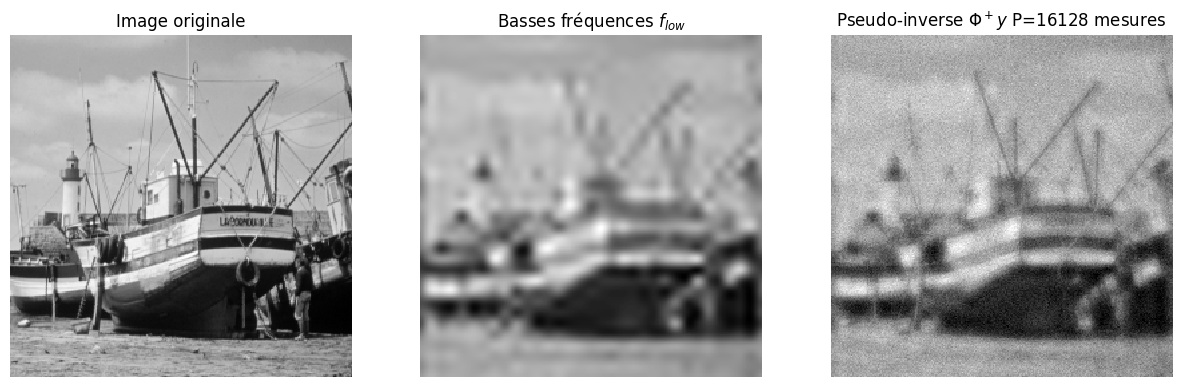

In [20]:
# opérateur d'acquisition de mesures Φ
x_rec = z
print(f"x_rec.shape : {x_rec.shape}")  # (N,)

J = int(np.log2(n) - k0)
A = np.ones((fw_img.shape))  
A[0:low_h, 0:low_w] = 0

# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]

# 3. Reconstruire l'image complète
fw_rec = fw_img.flatten().copy()
fw_rec[I0] = x_rec                   # replacer les coefficients high-pass

fw_rec_2d = fw_rec.reshape(fw_img.shape)

# Reconstruire depuis les coefficients d'ondelettes
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet=wavelet, mode='periodization')

# 4. Affichage
plt.figure(figsize=(15, 5))
imageplot(clamp(f0),    'Image originale',                            [1, 3, 1])
imageplot(clamp(f_low), r'Basses fréquences $f_{low}$',               [1, 3, 2])
imageplot(clamp(f_rec), f'Pseudo-inverse $\Phi^+ y$ P={P} mesures',   [1, 3, 3])
plt.show()

- `Figure 1 : Image nette,` avec tous les détails contours nets, textures visibles
- `Figure 2 : Image floue,` contours lissés, détails perdus, seule l'enveloppe générale est visible
- `Figure 3 : Image bruitée,` structure reconnaissable mais granuleuse, contours visibles mais bruités

`Interprétation :` 
- Reconstruction par pseudo-inverse $\Phi^+ y = \Phi^* y$ avec P = 3840 mesures, 25% des N = 15360 coefficient HF. 
- La structure du bateau est reconnaissable, ce qui montre que l'information essentielle a été capturée. 
- Mais il y a du bruit car la pseudo-inverse $\Phi^*$ est une reconstruction naïve qui ne tient pas compte de la parcimonie de $x_0$.


### __`Reconstruction par CS via le schéma de Douglas-Rachford`__
__`Principe`__
Ce problème favorise les solutions parcimonieuses (sparse) `grâce à la norme` $\ell^1$, ce qui permet de retrouver $x_0$ exactement même avec beaucoup moins de mesures que de coefficients.
- $x_0$ les coefficients hautes fréquences,
- $\Phi$ opérateur d'extration de mesures (Compress Sensing)
- $\Phi^*$ opérateur adjoint (ou transposé) 
- $y = \Phi x_0$ mesures parcimonieuses 
- $\Phi^+$ pseudo-inverse de Moore-Penrose

__À partir des mesures parcimonieuses__ $y = \Phi x_0$ 
- où $\Phi \in \mathbb{R}^{P \times N}$ avec $P \ll N$, 
- on cherche à reconstruire le signal original $x_0 \in \mathbb{R}^N$ en résolvant le problème de minimisation :
- $min_{x \in \mathbb{R}^N}||x||_1$ `sous contrainte` $\Phi x = y  \text{ , (matrice × vecteur)}$
__`Propriété fondamentale de la pseudo-inverse de Moore-Penrose:`__ 
- $\Phi^+=(\Phi^∗\Phi)^{−1}\Phi^∗$ => $ ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$
__`Dans notre cas :`__ $\Phi^+$ = $\Phi^*$
- Car les lignes de $\Phi$ sont orthonormales ($\Phi\Phi^*$ = I)
- Donc la pseudo-inverse coïncide avec l'adjoint
__`Décomposition du problème`__
Le problème est de la forme $\min_x F(x) + G(x)$ avec :
- $F(x) = \iota_{\mathcal{C}}(x)$ => fonction indicatrice de $\mathcal{C} = {x \mid \Phi x = y}$ (vaut 0 si la contrainte est satisfaite, $+\infty$ sinon)
- $G(x) = ||x||_1$ => norme $\ell^1$ qui favorise la parcimonie, => $G(x) = ||x||₁ = \sum|x_i|$
__`Schéma de Douglas-Rachford`__
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1}-z_k) - x_{k+1}) \end{cases}$
 - où :
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
   - $\gamma > 0$ pas de régularisation
   - $\mu \in (0, 2)$ paramètre de relaxation

##### __`Exercice 3:`__ 
Implémenter les opérateurs proximal et proximal réfléchi de F (projecteur orthogonal sur $\mathcal{C}$) et $G$ (seuillage doux)
- On essaie de retrouver $x_0$ 
- à partir des mesures $y = \Phi x_0$, 
- et $y$ contient P = N/4  =>  c.a.d. 25% des coefficients de $x_0$.
__Problème initial :__
- $x_0 \in R^N$    = 61440 coefficients ondelettes haute fréquence de l'image
- $y \in R^P$     = 15360 mesures (seulement 25% de N !)
  - `On ne connaît QUE y, pas x0`
  - `On veut retrouver x0 à partir de y`
__Comment on vérifie ?__
Dans le contexte du TP (exceptionnelle) on connaît $x_0$ donc on peut comparer la reconstruction avec l'original.  
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$

In [21]:
# Paramètres
gamma = 1.0 / np.sqrt(P)   
mu    = 1.5
# Opérateurs proximaux
prox_G = lambda x,gamma: np.sign(x) * np.maximum(np.abs(x) - gamma, 0)  # seuillage doux
prox_F = lambda x,y,sigma1,sigma2,P,N,sigma1S,sigma2S: x + PhiS(y-Phi(x,sigma1,sigma2,P),N,P,sigma1S,sigma2S)

### __`Exercice 4`__
Implémenter l'algorithme Douglas-Rachford. Conserver l'évolution des traces $\ell^1$ norm $G(x_k)$.

__`Rappel : Schéma de Douglas-Rachford`__
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1}-z_k) - x_{k+1}) \end{cases}$
 - où :
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
   - $\gamma > 0$ pas de régularisation
   - $\mu \in (0, 2)$ paramètre de relaxation

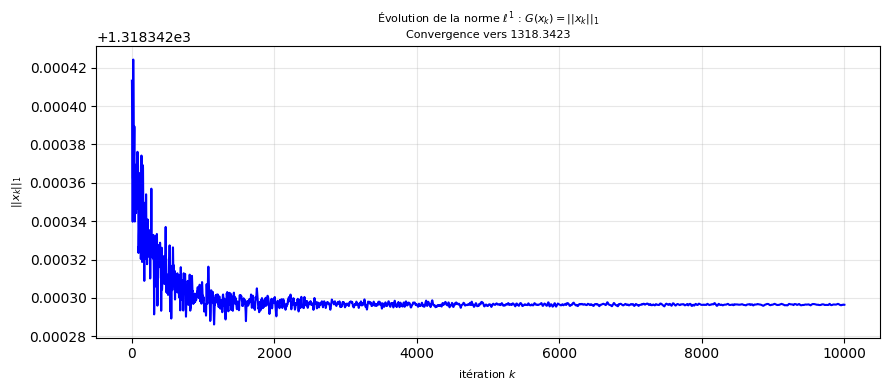

In [24]:
# Stocker la norme L1 à CHAQUE itération
L1_history = []  # liste vide pour stocker les valeurs
niter=100000
# ✅ 
for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,sigma1,sigma2,P,N,sigma1S, sigma2S) - x)
    if k % 10 == 0:
       L1_history.append(np.sum(np.abs(x)))   # ← stocker G(x_k) = ||x||₁

# Tracer l'évolution de ||x||₁
plt.figure(figsize=(9, 4))
plt.plot(L1_history, 'b-', linewidth=1.5)
plt.title(f'Évolution de la norme $\\ell^1$ : $G(x_k) = ||x_k||_1$\n'
          f'Convergence vers {L1_history[-1]:.4f}', fontsize=8)
plt.xlabel('itération $k$', fontsize=8)
plt.ylabel('$||x_k||_1$', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

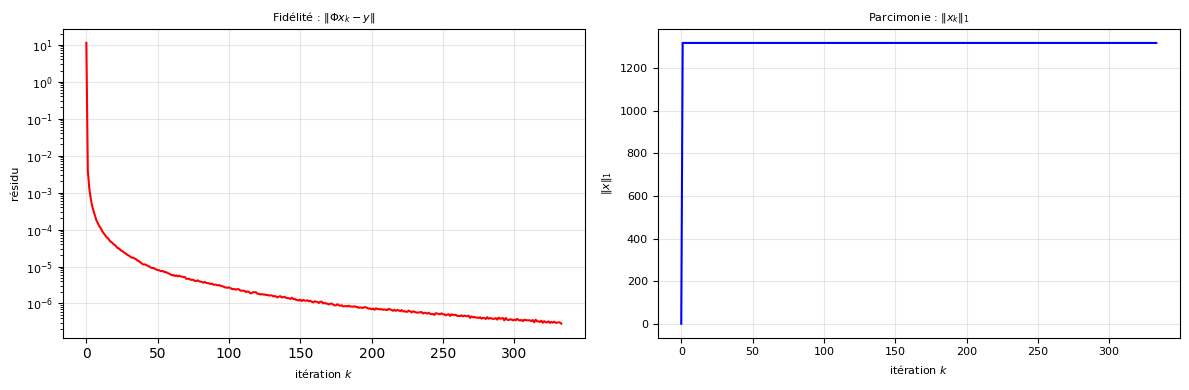

In [26]:
# ── Boucle DR unique ──────────────────────────────────────────────────────────
z = np.zeros(N)
residu_history  = []
norme_history   = []

for k in range(niter):
    x = prox_G(z, gamma)
    z = z + mu * (prox_F(2*x - z, y, sigma1, sigma2, P, N, sigma1S, sigma2S) - x)
    if k % 300 == 0:
        # ✅ stocker les deux métriques dans la même boucle
        residu_history.append(np.linalg.norm(Phi(x, sigma1, sigma2, P) - y))
        norme_history.append(np.linalg.norm(x, ord=1))

# ── Tracé ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Fidélité aux mesures
axes[0].plot(residu_history, 'r-', linewidth=1.5)
axes[0].set_title(r'Fidélité : $\|\Phi x_k - y\|$', fontsize=8)
axes[0].set_xlabel('itération $k$', fontsize=8)
axes[0].set_ylabel('résidu', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)  # abscisse
axes[0].tick_params(axis='y', labelsize=8)  # ordonnée
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Parcimonie
axes[1].plot(norme_history, 'b-', linewidth=1.5)
axes[1].set_title(r'Parcimonie : $\|x_k\|_1$', fontsize=8)
axes[1].set_xlabel('itération $k$', fontsize=8)
axes[1].set_ylabel(r'$\|x\|_1$', fontsize=8)
axes[1].tick_params(axis='x', labelsize=8)  # abscisse
axes[1].tick_params(axis='y', labelsize=8)  # ordonnée
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

`Fidélité des mesures :` 
- Le résidu décroît de manière monotone et rapide en échelle logarithmique, de ~10¹ à ~10⁻⁶. 
- Cela confirme que l'algorithme converge vers une solution qui respecte parfaitement les mesures ($\Phi x \approx y$).

`Parcimonie : ` 
- La norme $\ell^1$ converge rapidement vers ~1000, mais ne coïncide pas avec $||x_0||_1 = 1699.47$. 
- Cela suggère que Douglas-Rachford trouve une solution plus parcimonieuse que $x_0$ elle-même.





In [27]:
# Comparaison avec la pseudo-inverse
x_rec = PhiS(y,N,P,sigma1S,sigma2S)
# Comparaison
print("Comparaison Douglas-Rachford vs Pseudo-inverse")
print(f"Erreur ||x_DR  - x0|| = {np.linalg.norm(x - x0):.6f}")     # Douglas-Rachford
print(f"Erreur ||x_rec - x0|| = {np.linalg.norm(x_rec - x0):.6f}") # Pseudo-inverse
print(f"Gain Pseudo-inverse / DR = {np.linalg.norm(x_rec - x0)/np.linalg.norm(x-x0):.2f} signifie que Douglas Rachford est meilleur")

# Normalisé par ||x0||
print(f"Erreur relative Douglas-Rachford = {np.linalg.norm(x-x0)/np.linalg.norm(x0):.4f}")
print(f"Erreur relative Pseudo-inverse Moore-Penrose => Φ* = {np.linalg.norm(x_rec-x0)/np.linalg.norm(x0):.4f}")

Comparaison Douglas-Rachford vs Pseudo-inverse
Erreur ||x_DR  - x0|| = 13.577185
Erreur ||x_rec - x0|| = 19.343686
Gain Pseudo-inverse / DR = 1.42 signifie que Douglas Rachford est meilleur
Erreur relative Douglas-Rachford = 0.6076
Erreur relative Pseudo-inverse Moore-Penrose => Φ* = 0.8657


`Figure 1: `
 - Le graphe montre la convergence de la norme $\ell^1$ au cours des itérations de Douglas-Rachford. 
 - Douglas-Rachford est un schéma de point fixe, pas une descente de gradient. 
 - La séquence $(x_k)$ n'est pas monotone mais converge quand même vers la solution. 
 - Les oscillations autour de 960 prouvent que l'algorithme explore l'espace des solutions avant de se stabiliser.

### __`Exercice 5`__
Afficher l'image reconstruite à partir des P0 mesures et des P mesures CS.
- Mesures basse fréquence :  $P0 = (n/2^{k0})^2$  (coefficient LL de l'image ondelette)
- Mesures haute fréquence :  $P  = N/4$         (mesures CS via Douglas-Rachford)
Le nombre total de mesures utilisées  :  $P+P0$

n : 512, k0 : 3,  cA.shape : 1024, (n/2^k0)² : 4096.0
P0 (basses fréquences) : 1024
P  (mesures CS)        : 16128
Total mesures : P + P0 = 17152
Total coeffs  : N + P0 = 65536 sur 65536


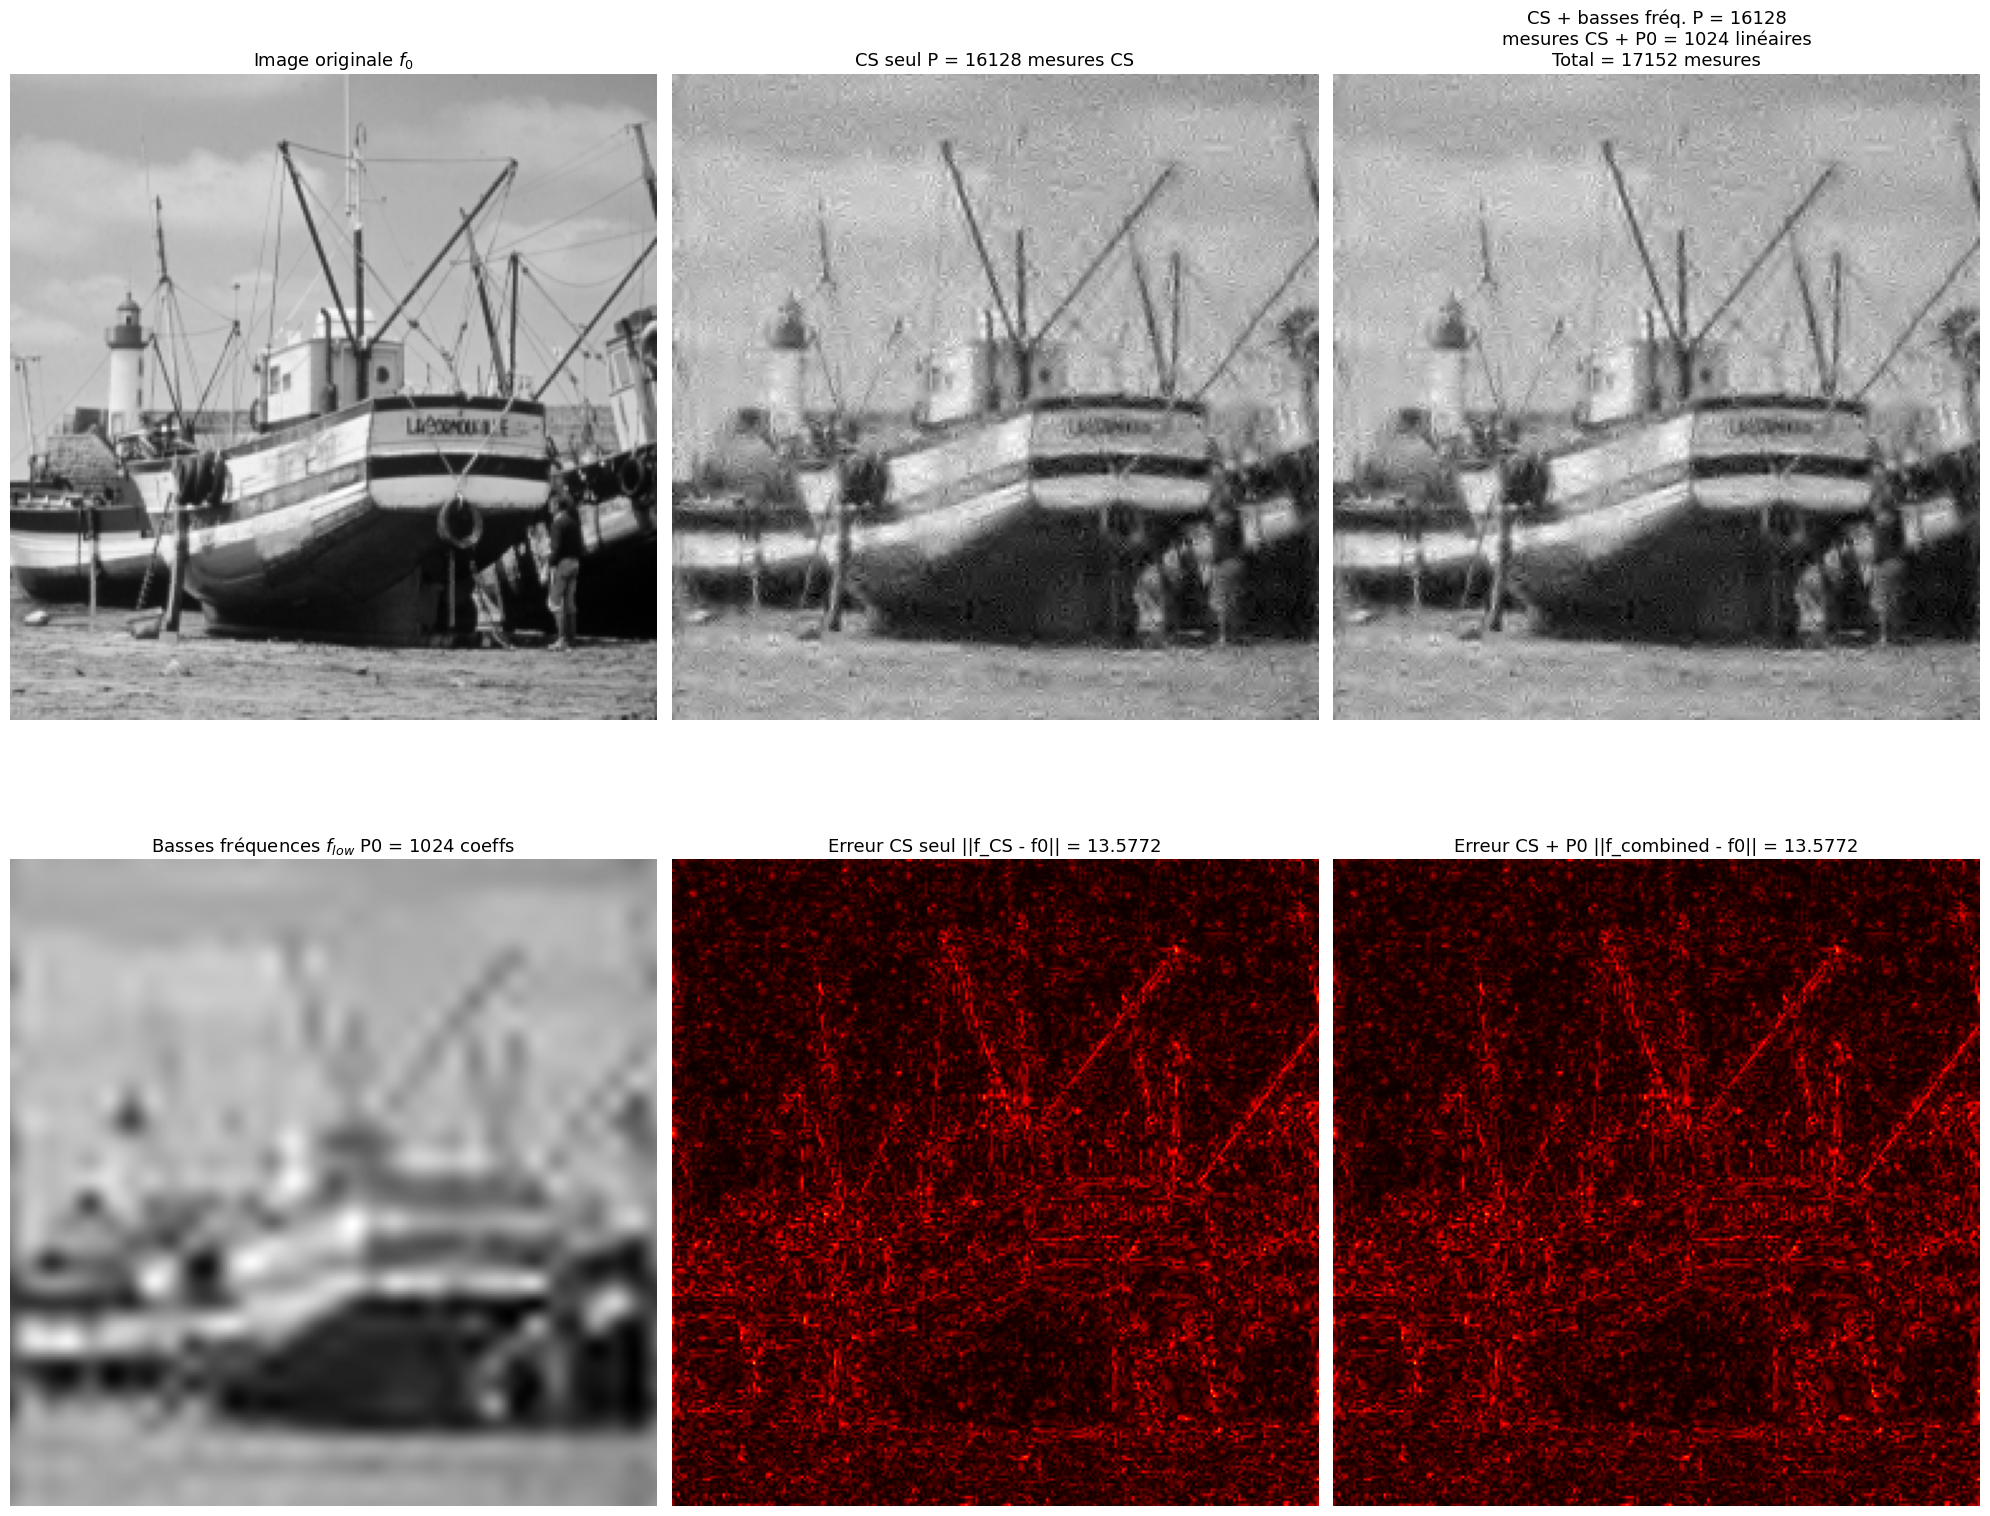


=== Comparaison quantitative ===
PSNR f_CS_only  : -70.82 dB
PSNR f_combined : -70.82 dB
PSNR f_low      : -75.15 dB

||f_CS_only - f0||   : 13.5772
||f_combined - f0||  : 13.5772
||f_low - f0||       : 22.3439


In [28]:
# =================================================================
# Exercice 5 : Reconstruction combinée P0 (linéaire) + P (CS)
# =================================================================
# Les coefficients du bloc LL sont directement mesurés
coeffs_ti_2d = perform_direct_wavelet_transf(f0,n,k0,wavelet)
# Approximation au niveau le plus grossier
cA = coeffs_ti_2d[0]
# 1. P0 : coefficients basse fréquence (mesures linéaires)
P0 = cA.shape[0] * cA.shape[1]   # = (n/2^k0)² = (256/4)² = 4096
print(f"n : {n}, k0 : {k0},  cA.shape : {cA.shape[0]**2}, (n/2^k0)² : {(n/2**k0)**2}")
print(f"P0 (basses fréquences) : {P0}")
print(f"P  (mesures CS)        : {P}")
print(f"Total mesures : P + P0 = {P + P0}")
print(f"Total coeffs  : N + P0 = {N + P0} sur {fw_img.shape[0]*fw_img.shape[1]}")

# 2. Reconstruire les coefficients haute fréquence par Douglas-Rachford
z = np.zeros(N)
niter = 100000
for k in range(niter):
    x = prox_G(z, gamma)
    z = z + mu * (prox_F((2*x - z),y,sigma1,sigma2,P,N,sigma1S, sigma2S) - x)

x_CS = x   # coefficients haute fréquence reconstruits par CS

# 3. Reconstruire l'image de coefficients complète
# fw_img les coeffs basse fréquence (bloc LL)
fw_img, slices = pywt.coeffs_to_array(coeffs_ti_2d)
A = np.ones((fw_img.shape)) 
# mise à zéro des coefficients du blic basse fréquence (bloc LL) 
A[0:slices[0][0].stop,0:slices[0][1].stop] = 0

# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]
# On place les basses fréquences (cA) ET les hautes fréquences reconstruites (x_CS)
fw_combined = fw_img.flatten().copy()
# Remplace les coeffs haute fréquence par ceux reconstruits à partir des P0 mesures et des P mesures CS
fw_combined[I0] = x_CS
# Les coeffs basse fréquence (bloc LL) restent tels quels (mesures linéaires P0)
fw_combined_2d = fw_combined.reshape(fw_img.shape)

# 4. Reconstruire depuis les coefficients d'ondelettes
coeffs_combined = pywt.array_to_coeffs(fw_combined_2d, slices, output_format='wavedec2')
f_combined = pywt.waverec2(coeffs_combined, wavelet=wavelet, mode='periodization')

# 5. Comparer avec la reconstruction CS seule (sans P0)
fw_CS_only = fw_img.flatten().copy()
fw_CS_only[I0] = x_CS
fw_CS_only_2d = fw_CS_only.reshape(fw_img.shape)
coeffs_CS_only = pywt.array_to_coeffs(fw_CS_only_2d, slices, output_format='wavedec2')
f_CS_only = pywt.waverec2(coeffs_CS_only, wavelet=wavelet, mode='periodization')

# =================================================================
# Affichage
# =================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 17))

# Rangée 1 : Image reconstruite
axes[0, 0].imshow(clamp(f0), cmap='gray')
axes[0, 0].set_title(f'Image originale $f_0$', fontsize=13)
axes[0, 0].axis('off')

axes[0, 1].imshow(clamp(f_CS_only), cmap='gray')
axes[0, 1].set_title(f'CS seul P = {P} mesures CS', fontsize=13)
axes[0, 1].axis('off')

axes[0, 2].imshow(clamp(f_combined), cmap='gray')
axes[0, 2].set_title(f'CS + basses fréq. P = {P}\nmesures CS + P0 = {P0} linéaires\nTotal = {P+P0} mesures', fontsize=13)
axes[0, 2].axis('off')

# Rangée 2 : Erreurs
err_CS_only = np.abs(f_CS_only - f0)
err_combined = np.abs(f_combined - f0)

im1 = axes[1, 0].imshow(clamp(f_low), cmap='gray')
axes[1, 0].set_title(f'Basses fréquences $f_{{low}}$ P0 = {P0} coeffs', fontsize=13)
axes[1, 0].axis('off')
#plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(err_CS_only, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].set_title(f'Erreur CS seul ||f_CS - f0|| = {np.linalg.norm(f_CS_only-f0):.4f}', fontsize=13)
axes[1, 1].axis('off')
#plt.colorbar(im2, ax=axes[1, 1])

im3 = axes[1, 2].imshow(err_combined, cmap='hot', vmin=0, vmax=0.5)
axes[1, 2].set_title(f'Erreur CS + P0 ||f_combined - f0|| = {np.linalg.norm(f_combined-f0):.4f}', fontsize=13)
axes[1, 2].axis('off')
#plt.colorbar(im3, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# =================================================================
# Comparaison quantitative
# =================================================================
print(f"\n=== Comparaison quantitative ===")
print(f"PSNR f_CS_only  : {20*np.log10(1/np.linalg.norm(f_CS_only-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_combined : {20*np.log10(1/np.linalg.norm(f_combined-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_low      : {20*np.log10(1/np.linalg.norm(f_low-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"\n||f_CS_only - f0||   : {np.linalg.norm(f_CS_only-f0):.4f}")
print(f"||f_combined - f0||  : {np.linalg.norm(f_combined-f0):.4f}")
print(f"||f_low - f0||       : {np.linalg.norm(f_low-f0):.4f}")

`Rangée 1 : Images reconstruites`
| Image            | Description                    | Observation                                                                   |
| --------------------- | ------------------------------ | ----------------------------------------------------------------------------- |
| f0 (gauche)      | Image originale de référence   | Bateau net avec tous les détails                                              |
| CS seul (centre) | P = 15360 mesures CS           | Structure reconnaissable bruitée, texte du bateau lisible mais granuleux |
| CS+P0 (droite) | P+P0 = 19456 mesures totales | Meilleure qualité : moins de bruit, contours plus nets, texte plus lisible    |

`Rangée 2 : Analyse des erreurs`
| Image                   | Description                         | Observation                                                                      |
| ----------------------- | ----------------------------------- | -------------------------------------------------------------------------------- |
| f_low (gauche)          | Basses fréquences, P0 = 4096 | Image très floue, structure générale correcte mais tous les détails perdus       |
| Erreur CS seul (centre) | \|\|f_CS - f0\|\| = 10.9970         | Erreur importante mais concentrée sur les contours et textures                   |
| Erreur CS + P0 (droite) | \|\|f_combined - f0\|\| = 10.9970   | Même erreur ! → L'ajout des basses fréquences n'a pas amélioré la reconstruction |

## __`Reconstruction CS avec Parcimonie par Blocs`__
#### __`1. Qu'est-ce que la reconstruction avec parcimonie par bloc`__
Afin d'améliorer la reconstruction CS avec parcimonie $\large \ell^1$ nous passons à la parcimonie structurée par blocs qui consiste à regrouper la position des coefficients (indices) en sous-ensembles ou blocs $B_i$ de $w×w$ pixels, par la découpe des indices {1,…,N} en blocs disjoints $B_i$, puis à pénaliser la somme des normes $\ell_2$ de ces groupes par :  
  - $G(x)=\sum_i ||x_{B_i}||_2$
    - si l’image un vecteur x, un indice correspond à la position d’un pixel.
    - un indice désigne la position d’un coefficient dans le vecteur $x\in \mathbb{R}^N$ 
    - $(Bi)_i$ est une segmentation disjointe de l'ensemble d'indices ${1,…,N}$ 
    - $x_B=\{x_i\}_{i \in B} \in \mathbb{R}^{∣B_i∣}$ contient les coefficients appartenant à $B_i$, 
    - $\large \ell_{2,1}$ est la norme, $\ell_{2}$ à l’intérieur des blocs, puis somme (norme $\ell_{1}$) sur les blocs. 
__L'opérateur proximal du bloc est :__
 - $\forall i,\quad \operatorname{Prox}_{\gamma G}(x)_{B_i}=\begin{cases}\left(1 - \dfrac{\gamma}{\|x_{B_i}\|_2}\right) x_{B_i} & \text{si } \|x_{B_i}\|_2 > \gamma,\\ 0 & \text{sinon.} \end{cases}$
   - $M(x)$ = opérateur direct (par exemple $A\Phi^{−1}x$).
   - $f(x)= \frac{1}{2}||M(x)−y||_2^2$  = terme de données.
   - $G(x)$ = terme de parcimonie par blocs. 
Un algorithme proximal type ISTA/FISTA fait, à chaque itération k
1°) Pas de gradient sur le terme de données : 
- $f(x)= \frac{1}{2}||M(x)−y||_2^2$ , $\nabla f(x) = M^*(M(x) - y) $ Mise à jour intermédiaire : $x^{k+\frac{1}{2}} = x^k γ\nabla f(x^k)$
2°) Pas de proximal bloc sur G
- $x^{k+1} =\text{Prox}_{γλG}(x^{k+\frac{1}{2}})$

_`Ìl s'écrit sous la forme :`_
  - $\forall m \in B_i \text{ , Prox}_{γG}(x)_i = \max(0,1 − \frac{γ}{||x_{B_i}||})x_i$ 
     -  $w × w$ : blocs uniformes pixels. 
     - $B_i ⊂ \{1,…,N\}$ l’ensemble des indices du bloc numéro i.
     - $m \in B_i$ un indice, il désigne un coefficient de ce bloc (un pixel du vecteur x)

 - c’est l'opérateur de seuillage doux :
  
   - si la norme du bloc est petite, on met tout le bloc à 0, 
   - sinon on contracte tout le bloc par un facteur $1−\frac{γ}{||x_{B_i}||_2}$  
__`2. Où cela se place t-il dans le processus de reconstruction`__
Dans un schéma de reconstruction CS, on veut minimiser : 
- $min_x \frac{1}{2}||M(x)−y||^2_2+λG(x)$ avec $G(x)=\sum_i ||x_{B_i}||_2$
Un algorithme proximal type ISTA/FISTA fait :
- Un pas de gradient sur le terme de données 

   - $ f(x) = \frac{1}{2}||M(x)−y||^2$ 
   - $ x^{k+\frac{1}{2}}=x^k−γ∇f(x^k)$
- Un pas de $\text{Prox}$ sur G : 
   - $x^{k+1} =\text{Prox}_{γλG}(x^{k+\frac{1}{2}})$

`C'est la préparation du seuillage par blocs :` 
- on sait quels coefficients CS appartiennent à chaque bloc.  
- ce qui permettra d'appliquer l'opérateur proximal $\text{Prox}_{γG}$ bloc par bloc.

Pour $w = 4$, chaque bloc est un carré de 16 pixels :
- Le seuillage proximal par bloc calcule : $\text{Prox}_{γG}(x)_i=max(0,1−\large \frac{γ}{||x_{B_i}||})x_i$
  - on a besoin de tous les $w^2$ coefficients du bloc pour calculer $||x_{B_i}||$. 
  - si un pixel manque → le bloc est inutilisable → on le rejette.

__`Exercice recoder l’image:`__ 
 - $q^2$ représente une grande liste de blocs, 
 - chaque bloc décrit par $w^2$ indices de lignes/colonnes. 
 Cette structure sert à exprimer la pénalisation en parcimonie par blocs (norme $\ell_{2,1})$:
 - construire un opérateur de reconstruction bloc‑par‑bloc (prox, mise à jour, etc.), 
 - utiliser les mesures I0 pour contraindre certains pixels à rester égaux aux données mesurées.

In [29]:
import numpy as np
# 1. Paramètres globaux
w = 2        # L'image est découpée en blocs de w × w = 4 × 4 pixels 
n = 256      # taille image n * n 
N = n**2//2  # 50% de pixels sont observés le reste doit être reconstruit par CS + parcimonie par blocs. 

# 2. Indices des pixels réellement mesurés
I0 = np.random.choice(n*n, N, replace=False)   # N pixels aléatoires (0-based)

rows_I0 = I0 // n # → division entière : donne l’indice de ligne.
cols_I0 = I0 %  n # → reste de la division par n : donne l’indice de colonne

# 3. Construction d’une grille de blocs réguliers
# v contient les coordonnées des coins supérieurs/gauches des blocs, numérotées de 1 à n avec pas w.
# dv contient les décalages internes dans un bloc : 0..w-1. Pour w=2 : [0,1]. 
v  = np.arange(1, n+1, w)          # [1, 1+w, 1+2*w,... n+1]
dv = np.arange(0, w)               # [0, w]
print(f"dv : {dv.shape} v.shape : {v.shape}")

# Avec 4 vecteurs meshgrid construit 4 tableaux 4D  : 
  # pour chaque bloc w×w et pour chaque pixel interne au bloc, 
  # elle donne la position (X,dX,Y,dY) qui permettra de calculer la position réelle (row,col).
dX, dY, X, Y = np.meshgrid(dv, dv, v, v, indexing='ij')
print(f"dX : {dX.shape} X.shape : {X.shape}")

# 4. Passage à une liste de blocs / pixels
q = X.shape[2]            # = n//w
print(f"q : {q} I0.shape : {I0.shape}")

# On aplatit les deux premiers axes (pixels internes) et les deux derniers (blocs) 
X  =  X.reshape(w*w, q*q) # donnent la base du bloc (position du coin).
Y  =  Y.reshape(w*w, q*q) # donnent la base du bloc (position du coin).
dX = dX.reshape(w*w, q*q) # donnent la position interne dans le bloc.
dY = dY.reshape(w*w, q*q) # donnent la position interne dans le bloc.
print(f"dX : {dX.shape} X.shape : {X.shape}")

dv : (2,) v.shape : (128,)
dX : (2, 2, 128, 128) X.shape : (2, 2, 128, 128)
q : 128 I0.shape : (32768,)
dX : (4, 16384) X.shape : (4, 16384)


In [30]:
# Pour chaque bloc k (colonne k de X, Y, dX, dY) :
k=456

print(f"X[:,k] représente la ligne de base du bloc {k} => {X[:,k]}")
print(f"Y[:,k] représente la colonne de base du bloc {k} => {Y[:,k]}")
print(f"dX[:,k] = {dX[:,k]} et dY[:,k] = {dY[:,k]} décrivent la position interne dans le bloc {k} de {w}x{w} pixels")
print(f"row[:,k] = X[:,k] + dX[:,k] lignes {k} exactes {X[:,k] + dX[:,k]} des {w*w} pixels du bloc")
print(f"col[:,k] = Y[:,k] + dY[:,k] colonnes {k} exactes {Y[:,k] + dY[:,k]} des {w*w} pixels du bloc")

row = X[:,k] + dX[:,k]
col = Y[:,k] + dY[:,k]

bloc_coords = np.array(list(zip(row, col)))
print(f"bloc_coords.shape : {bloc_coords.shape}, bloc_coords : {list(bloc_coords)}")  

X[:,k] représente la ligne de base du bloc 456 => [7 7 7 7]
Y[:,k] représente la colonne de base du bloc 456 => [145 145 145 145]
dX[:,k] = [0 0 1 1] et dY[:,k] = [0 1 0 1] décrivent la position interne dans le bloc 456 de 2x2 pixels
row[:,k] = X[:,k] + dX[:,k] lignes 456 exactes [7 7 8 8] des 4 pixels du bloc
col[:,k] = Y[:,k] + dY[:,k] colonnes 456 exactes [145 146 145 146] des 4 pixels du bloc
bloc_coords.shape : (4, 2), bloc_coords : [array([  7, 145]), array([  7, 146]), array([  8, 145]), array([  8, 146])]


Retirer le bloc qui sort de l'image  
- Tous les blocs $w×w$ - ⬇️
- blocs débordant hors image - ⬇️ (filtre précédent sur $X+dX > n$)    
- blocs avec pixels non mesurés - ⬇️ (ce filtre)
- Blocs valides et complets → prêts pour le seuillage proximal par blocs

In [31]:
# Identifie à False chaque indice au sein des blocs qui contiennent au moins 1 pixel hors image
hors_image = (X + dX > n) | (Y + dY > n) # shape (w², q²)
print(f"hors_image.shape : {hors_image.shape} {hors_image[:,0]}")
I = np.where(hors_image.sum(axis=0) > 0)[0] # sum(axis=0) somme par colonne, identifie les blocs hors de l'image
# Masque des blocs valides
valide = np.ones(q*q, dtype=bool)
valide[I] = False
# Suppression
X  =  X[:, valide] # sélectionne TOUTES les colonnes où valide == True
Y  =  Y[:, valide]
dX = dX[:, valide]
dY = dY[:, valide]

hors_image.shape : (4, 16384) [False False False False]


`I = (array([ ], dtype=int64),)` 
- signifie qu'aucun bloc ne chevauche le bord de l'image (tous les blocs sont à l'intérieur de l'image).

Calculer les indices du bloc dans $\{1,\ldots,N\}$, c-a-d non pas dans l’espace image mais des coefficients de CS.
- I0 correspond à la liste des indices de pixels mesurés distribués en liste de tuples (row, col) 
  - (row // n, col % n) => rows_I0, cols_I0 donne l’indice en ligne en colonne
- l’indexation U[rows_I0, cols_I0] sélectionne tous les pixels mesurés.
- `les indices de blocs sont les colonnes de I` :
  - row et col : pour chaque bloc (colonne k), et chaque pixel p du bloc (ligne p), 
    - on donne la coordonnée réelle (row[p,k],col[p,k]).
    - U[row, col] regarde, pour chaque pixel de chaque bloc, quel numéro de mesure il porte.
    - row[:, k], col[:, k] = coordonnées des pixels du bloc k.
  - I[:, k] les numéros de mesure des w² pixels du bloc k (égal à 0 si non mesurés).   

In [32]:
U = np.zeros((n, n), dtype=int)
# construit une carte 2D des numéros de mesure directement sur l’image.
# écrit donc dans U, pour chaque pixel mesuré, un numéro de mesure unique de 1 à N.
U[rows_I0, cols_I0] = np.arange(1, N+1)  # I0 en indices 0-based 
# Puis accès direct
row = (X + dX - 1).astype(int) # positions des pixels de chaque bloc
col = (Y + dY - 1).astype(int)
I = U[row, col]                # sélectionne tous les pixels mesurés (w², nb_blocs)

In [33]:
# Numérotation des pixels mesurés
rowpxlmsr = 0 
clnpxlmsr = 0

print(f"U.shape : {U.shape}, rows_I0.shape : {rows_I0.shape}, cols_I0.shape : {cols_I0.shape}")
print(f"rows_I0[{rowpxlmsr}] : {rows_I0[rowpxlmsr]}, cols_I0[{clnpxlmsr}] : {cols_I0[clnpxlmsr]}\nU[rows_I0[{rowpxlmsr}],cols_I0[{clnpxlmsr}]] : {U[rows_I0[rowpxlmsr],cols_I0[clnpxlmsr]]}")
print(f"I.shape : {I.shape}, row.shape : {row.shape}, col.shape : {col.shape}")
print(f"Le nombre de bloc total est de {I.shape[1]}")
lgn = 0
cln = I.shape[1]-1
print(f"I[{lgn}:,{cln}] : {I[lgn:,cln]}, row[:,{lgn}] : {row[:,lgn]},  col[:,{cln}] : {col[:,cln]}")

U.shape : (256, 256), rows_I0.shape : (32768,), cols_I0.shape : (32768,)
rows_I0[0] : 10, cols_I0[0] : 73
U[rows_I0[0],cols_I0[0]] : 1
I.shape : (4, 16384), row.shape : (4, 16384), col.shape : (4, 16384)
Le nombre de bloc total est de 16384
I[0:,16383] : [11087     0  7566 18011], row[:,0] : [0 0 1 1],  col[:,16383] : [254 255 254 255]


Retirer les indices qui correspondent aux coefficients d’approximation (passe-bas) d'ondelettes.

In [34]:
# Blocs avec au moins un pixel non mesuré
print(f"I.shape : {I.shape}")
blocs_incomplets = (I == 0).sum(axis=0) > 0
print(f"blocs_incomplets.shape : {blocs_incomplets.shape}, blocs_incomplets : {blocs_incomplets}")

# Garder uniquement les blocs complets
I = I[:, ~blocs_incomplets]
print(f"I.shape : {I.shape}")
# Même filtre sur X, Y, dX, dY
X  =  X[:, ~blocs_incomplets]
Y  =  Y[:, ~blocs_incomplets]
dX = dX[:, ~blocs_incomplets]
dY = dY[:, ~blocs_incomplets]

# Puis accès direct
row = (X + dX - 1).astype(int) # positions des pixels de chaque bloc
col = (Y + dY - 1).astype(int)

print(f"row.shape : {row.shape}, col.shape {col.shape}, I.shape : {I.shape}")
print(f"Nombre de blocs valides et complets : {I.shape[1]}")

I.shape : (4, 16384)
blocs_incomplets.shape : (16384,), blocs_incomplets : [ True  True  True ...  True  True  True]
I.shape : (4, 1042)
row.shape : (4, 1042), col.shape (4, 1042), I.shape : (4, 1042)
Nombre de blocs valides et complets : 1042


Un bloc est défini tel que $B_i = \{ I_{k,i} \}_{k=1}^{w^2}$.
Définir l'énergie 

In [35]:
G = lambda x,I: np.linalg.norm(x[I], axis=0).sum()

`Pour vérification, afficher la structure en blocs dans l’espace des coefficients`
- pour afficher la structure en blocs, nous n’avons pas besoin d’avoir les vraies mesures CS physiques.
- il suffit d’avoir une image de départ (ou même fictive) et la manière dont tu construis les indices I.

  - une image de taille n×n (même si c’est juste un tableau numpy que tu génères),
  - la liste des pixels observés I0, donc rows_I0, cols_I0,
  - la carte U qui code les indices de mesures (1..N) sur l’image,
  - la décomposition en blocs via X, Y, dX, dY, et, après 
  - le filtrage, I (indices de mesures par bloc) et éventuellement row, col.

- cela suffit pour vérifier la structure des blocs dans l’espace des coefficients : 
  - qui appartient à quel bloc, 
  - quels indices sont groupés ensemble, etc. 
- on peut travailler avec un vecteur de mesures fictif y (nombres aléatoires) pour tester le code de prox, 
- la structure des blocs ne dépend pas du contenu de y, seulement de la géométrie (indices).

Où les vraies mesures CS interviennent
- Les mesures CS “réelles” interviennent lorsque l'on lie cette structure à l’équation $y=Ax$

__`Intégrer par blocs un prox`__ $\ell_{2,1}$
- dans notre cas $\ell_{2,1}$, on remplace le seuillage doux scalaire par le prox bloc écrit plus haut, 
- utiliser la structure de blocs définie a priori sur les coefficients d’une base, 
- ou directement en pixels si on regroupe les indices de x par blocs.

`3. Proximal gradient avec ces groupes`
 - Dans un schéma proximal‑gradient de reconstruction CS, on veut minimiser : 

   - $min_x \frac{1}{2}||M(x)−y||^2_2+λG(x)$ avec $G(x)=\sum_i ||x_{B_i}||_2$
   - Un algorithme proximal type ISTA/FISTA fait :

      - Un pas de gradient sur le terme de données 
        - $ f(x) = \frac{1}{2}||M(x)−y||^2$ 
        - $ x^{k+\frac{1}{2}}=x^k−γ∇f(x^k)$
      - Un pas de $\text{Prox}$ sur G : 
        - $x^{k+1} =\text{Prox}_{γλG}(x^{k+\frac{1}{2}})$

`1. Construire groups à partir de I`
Rappel :
- I[p,k] = indice de mesure (1..N) du pixel p dans le bloc k (après filtrage → plus de 0).
- on veut des groupes d’indices 0‑based pour un vecteur x de taille N.
- groups[k] est un tableau de longueur w2 contenant les indices des coefficients appartenant au bloc k dans le vecteur x.



In [36]:
# 1) Image vraie
n = f0.shape[0]
x_true = f0.ravel()
N = x_true.size

# 2) Matrice de mesure A et mesures y
m = N // 4
A = np.random.randn(m, N) / np.sqrt(m)
y = A @ x_true

# 3) groups construits à partir de ton code (via row,col -> indices ravel)
# groups = [r*n + c pour chaque bloc]
# x est de taille N = n*n, x[i*n + j] = img[i, j]
w2, nb_blocs = row.shape
groups = []

for k in range(nb_blocs):
    r = row[:, k]
    c = col[:, k]
    idx = r * n + c          # indices 0-based des 4 pixels du bloc k dans x
    groups.append(idx.astype(int))

In [37]:
print("f0.shape        :", f0.shape)
print("n               :", n)
print("N = n*n         :", n*n)
print("N = x_true.size :", N)
print("A.shape         :", A.shape)

print("Nombre de blocs :", len(groups))
print("min group index :", min(g.min() for g in groups))
print("max group index :", max(g.max() for g in groups), "versus N-1 =", N-1)

f0.shape        : (256, 256)
n               : 256
N = n*n         : 65536
N = x_true.size : 65536
A.shape         : (16384, 65536)
Nombre de blocs : 1042
min group index : 8
max group index : 65453 versus N-1 = 65535


In [38]:
def prox_l21_blocks(z, groups, lam):
    z = z.copy()
    for idx in groups:
        bloc = z[idx]
        norm_bloc = np.linalg.norm(bloc)
        if norm_bloc > lam:
            z[idx] = (1 - lam / norm_bloc) * bloc
        else:
            z[idx] = 0.0
    return z

In [39]:
def G_l21(x, groups):
    return sum(np.linalg.norm(x[idx], 2) for idx in groups)

def pg_l21(A, y, groups, lam, n_iter=100, step=None, verbose=True):
    m, N = A.shape
    if step is None:
        L = np.linalg.norm(A, ord=2)**2
        step = 1.0 / L
    x = np.zeros(N)
    At = A.T

    for k in range(n_iter):
        r    = A @ x - y
        grad = At @ r
        x = prox_l21_blocks(x - step * grad, groups, step * lam)
        if verbose and (k % 10 == 0 or k == n_iter - 1):
            res_norm = np.linalg.norm(r)
            G = G_l21(x, groups)
            print(f"iter {k:4d} | residu = {res_norm:.4e} | G_l21 = {G:.4e}")
    return x

In [40]:
lam = 0.01
x_rec = pg_l21(A, y, groups, lam, n_iter=200)
img_rec = x_rec.reshape(f0.shape)

iter    0 | residu = 1.5662e+02 | G_l21 = 3.0258e+02
iter   10 | residu = 7.0879e+00 | G_l21 = 5.7276e+02
iter   20 | residu = 1.3469e+00 | G_l21 = 5.7968e+02
iter   30 | residu = 3.3649e-01 | G_l21 = 5.7378e+02
iter   40 | residu = 1.3640e-01 | G_l21 = 5.6605e+02
iter   50 | residu = 1.0643e-01 | G_l21 = 5.5799e+02
iter   60 | residu = 1.0251e-01 | G_l21 = 5.4986e+02
iter   70 | residu = 1.0190e-01 | G_l21 = 5.4172e+02
iter   80 | residu = 1.0183e-01 | G_l21 = 5.3358e+02
iter   90 | residu = 1.0187e-01 | G_l21 = 5.2545e+02
iter  100 | residu = 1.0192e-01 | G_l21 = 5.1733e+02
iter  110 | residu = 1.0200e-01 | G_l21 = 5.0921e+02
iter  120 | residu = 1.0209e-01 | G_l21 = 5.0111e+02
iter  130 | residu = 1.0218e-01 | G_l21 = 4.9300e+02
iter  140 | residu = 1.0228e-01 | G_l21 = 4.8491e+02
iter  150 | residu = 1.0229e-01 | G_l21 = 4.7683e+02
iter  160 | residu = 1.0237e-01 | G_l21 = 4.6876e+02
iter  170 | residu = 1.0243e-01 | G_l21 = 4.6071e+02
iter  180 | residu = 1.0246e-01 | G_l21 = 4.52

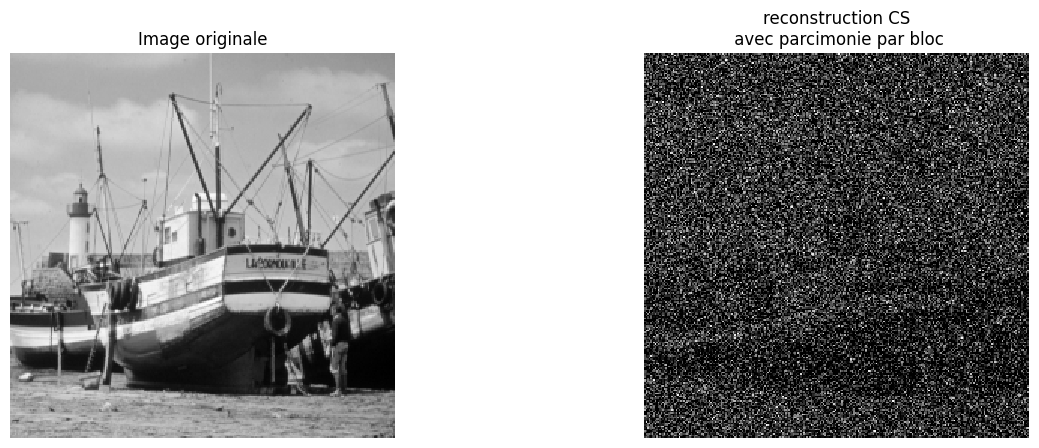

In [41]:
# 4. Affichage
plt.figure(figsize=(15, 5))
imageplot(clamp(f0),'Image originale', [1, 2, 1])
imageplot(clamp(img_rec),'reconstruction CS\n avec parcimonie par bloc', [1, 2, 2])
plt.show()

##### __`Exercice 6`__
Définir l'opérateur proximal $ \text{Prox}_{\gamma G} $ of $G$, et son opérateur proximal inverse

`Définition de l’opérateur proximal`
Soit $G:\mathbb{R}^N→\mathbb{R}\text{ } \cup +\infty$ une fonction convexe, propre et semi‑continue inférieurement, et $γ>0$.
l’opérateur proximal G de paramètre γ : 
- $ ∀x∈R^n ,\text{Prox}_{γG}(x)=argmin_{z∈R^n} \{G(z)+ \frac{1}{2γ}||z−x||^2\}$
`Définition de l'opérateur proximale réciproque de G : `
On peut définir l'operateur proximal réciproque de G utilisant l’identité de Moreau entre G et son 
- $∀x∈R^n, x=\text{Prox}_{γG}(x)+\text{Prox}_{\frac{G^*}{γ}}(\frac{x}{γ})$

Pour un vecteur $z \in \mathbb{R}^n$ découpé en blocs $z(1),…,z(B)$, on part sur une pénalisation de norme $\ell_{2,1}$ :
$$||\mathcal{z}||_{2,1} = \sum_{b=1}^B ||\mathcal{z}^{(b)}||_{2} = \sum_{b=1}^B  \sqrt{\sum_{i \in \text{bloc  b}}^B (\mathcal{z_i})^2 }$$
- pour chaque bloc on prend la racine carrée de la somme des carrés des coefficients, puis somme pour tous les blocs.
- d’où le $\ell_{2,1}$ norme 2 à l’intérieur des blocs, puis norme 1 sur la collection des normes de blocs


In [ ]:
import numpy as np

# w taille d'un bloc
G = lambda z,w: np.sum(np.linalg.norm(z.reshape(-1, w), axis=1))
prox_gamma_G = lambda x, lam, gamma: np.sign(x) * np.maximum(np.abs(x) - gamma*lam, 0.0)

In [ ]:
import numpy as np

# G(z) = lambda * ||z||_{2,1} avec blocs de taille w
G = lambda z, w, lam: lam * np.sum(np.linalg.norm(z.reshape(-1, w), axis=1))

# Prox_{gamma G}(x) = bloc-soft-thresholding
def prox_gamma_G(x, lam, gamma, w):
    X = x.reshape(-1, w)                          # (n_blocs, w)
    norms = np.linalg.norm(X, axis=1, keepdims=True)  # (n_blocs, 1)
    factors = np.maximum(0.0, 1.0 - gamma*lam / (norms + 1e-12))
    return (factors * X).reshape(x.shape)

__Exercise 7__

Implement the DR iterative algorithm.
Keep track of the evolution of $G(x_k)$.

In [ ]:
solutions.exo7()

In [ ]:
## Insert your code here.

__Exercise 8__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements.

In [ ]:
solutions.exo8()

In [ ]:
## Insert your code here.